# 06 — Model Inspection and Visual Results

**Goal:**  
Visualize predictions from the fine-tuned YOLOv8 model and qualitatively evaluate performance.

This notebook:
1. Loads the fine-tuned model  
2. Runs detection on a selected folder of images  
3. Draws bounding boxes with class-colored labels  
4. Saves the visualized results to `outputs/detections/`  
5. Optionally compares predictions with ground-truth labels (if available)

**Based on:** `check_bboxes.py`

In [4]:
# === Imports and Configuration ===
import os
import cv2
import random
from ultralytics import YOLO
import matplotlib.pyplot as plt

# === Import shared config ===
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from config import CLASSES

# === Paths ===
MODEL_PATH = "runs/detect/epic_full_epoch/weights/best.pt"  # fine-tuned model
INPUT_FOLDER = "/home/server/EPIC-KITCHENS/P04/rgb_frames/P04_117"    # example folder
OUTPUT_FOLDER = "./outputs/detections"
CONF_THRESHOLD = 0.5

# === Prepare output folder ===
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print(f"✅ Model: {MODEL_PATH}")
print(f"✅ Input folder: {INPUT_FOLDER}")
print(f"✅ Output folder: {OUTPUT_FOLDER}")

✅ Model: runs/detect/epic_full_epoch/weights/best.pt
✅ Input folder: /home/server/EPIC-KITCHENS/P04/rgb_frames/P04_117
✅ Output folder: ./outputs/detections


## Step 1 — Load Fine-Tuned YOLO Model

In [5]:
model = YOLO(MODEL_PATH)
print("✅ Model loaded successfully.")

✅ Model loaded successfully.


## Step 2 — Run Inference on a Folder of Images

In [6]:
# Get list of all image files
image_files = [f for f in os.listdir(INPUT_FOLDER)
               if f.lower().endswith((".jpg", ".jpeg", ".png"))]

print(f"🔍 Processing {len(image_files)} images...")

for img_name in image_files:
    img_path = os.path.join(INPUT_FOLDER, img_name)
    results = model.predict(source=img_path, conf=CONF_THRESHOLD, verbose=False)

    result = results[0]
    boxes = result.boxes.xyxy.cpu().numpy()  # (x1, y1, x2, y2)
    confs = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)
    names = result.names

    # Read original image
    image = cv2.imread(img_path)
    H, W = image.shape[:2]

    # Generate consistent color map for classes
    random.seed(42)
    colors = {cls_name: (random.randint(0,255), random.randint(0,255), random.randint(0,255)) for cls_name in names.values()}

    # Draw detections
    for box, conf, cls_id in zip(boxes, confs, classes):
        x1, y1, x2, y2 = map(int, box)
        label = names[cls_id]
        color = colors[label]
        text = f"{label} {conf:.2f}"

        # Draw rectangle and label
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(image, text, (x1, max(25, y1 - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    # Save processed image
    out_path = os.path.join(OUTPUT_FOLDER, img_name)
    cv2.imwrite(out_path, image)

print(f"✅ Detection completed. Results saved to: {OUTPUT_FOLDER}")

🔍 Processing 16758 images...
✅ Detection completed. Results saved to: ./outputs/detections


## Step 3 — Display Sample Predictions
Let's visualize a few results directly inside the notebook.

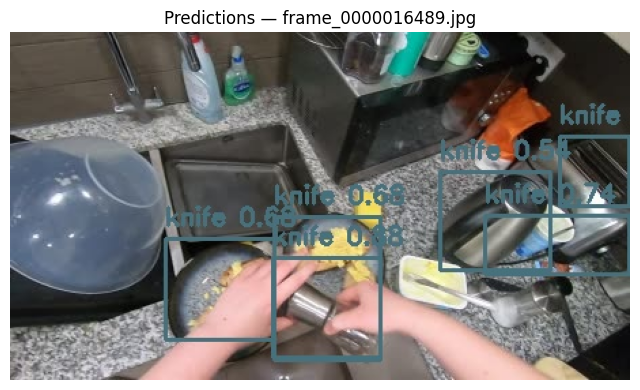

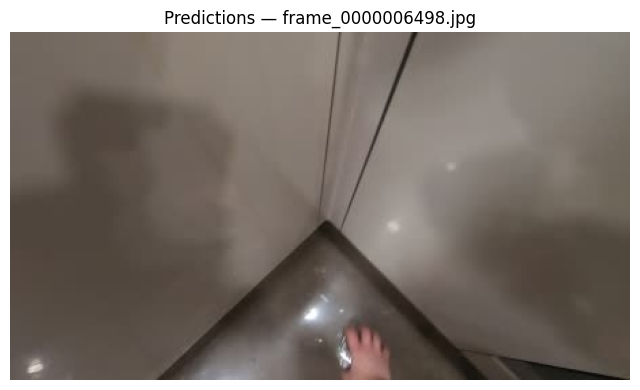

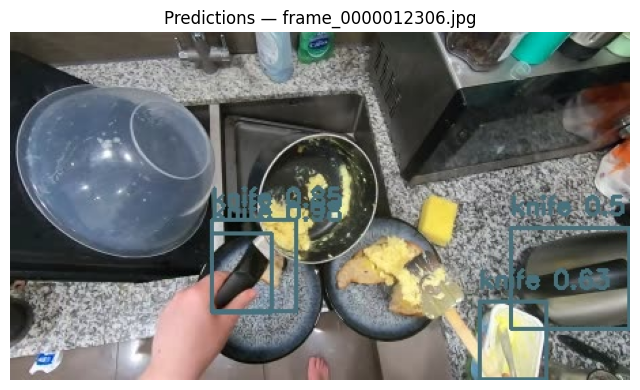

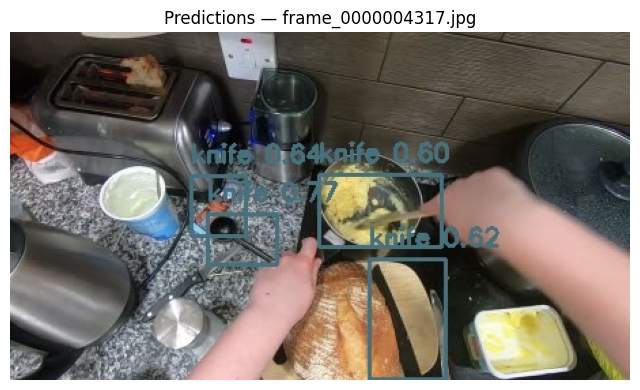

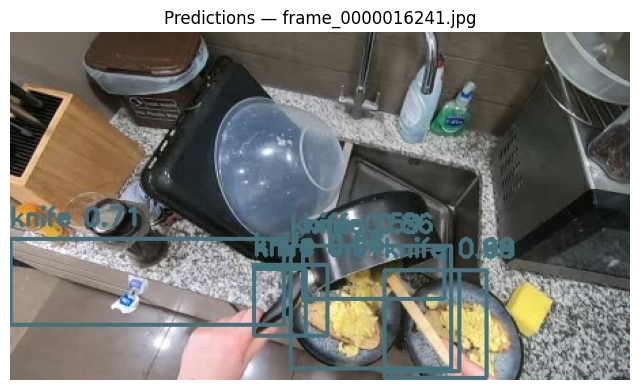

In [7]:
sample_images = random.sample(image_files, min(5, len(image_files)))

for img_name in sample_images:
    img_path = os.path.join(OUTPUT_FOLDER, img_name)
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f"Predictions — {img_name}")
    plt.axis("off")
    plt.show()

## 🧩 Step 4— Compare with Ground Truth Labels

If label `.txt` files exist for these images (YOLO format), you can overlay both prediction and ground truth boxes.

In [8]:
import glob

LABELS_DIR = os.path.join(os.path.dirname(INPUT_FOLDER), "labels")

if os.path.exists(LABELS_DIR):
    print(f"Comparing with labels in: {LABELS_DIR}")
    for img_name in random.sample(image_files, min(3, len(image_files))):
        label_file = os.path.join(LABELS_DIR, img_name.replace(".jpg", ".txt"))
        if not os.path.exists(label_file):
            continue

        img_path = os.path.join(OUTPUT_FOLDER, img_name)
        img = cv2.imread(img_path)
        H, W = img.shape[:2]

        with open(label_file, "r") as f:
            lines = f.readlines()

        for line in lines:
            cls_id, xc, yc, wn, hn = map(float, line.split())
            cls_name = CLASSES[int(cls_id)]
            x1 = int((xc - wn/2) * W)
            y1 = int((yc - hn/2) * H)
            x2 = int((xc + wn/2) * W)
            y2 = int((yc + hn/2) * H)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 255, 0), 2)
            cv2.putText(img, f"GT: {cls_name}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Predictions vs Ground Truth — {img_name}")
        plt.axis("off")
        plt.show()
else:
    print("⚠️ No ground-truth labels found. Skipping comparison.")

⚠️ No ground-truth labels found. Skipping comparison.


## Summary

**Outputs:**
- Visual predictions for fine-tuned model  
- Bounding boxes with class-specific colors  
- Optional overlay with ground truth labels  

**Output Folder:** `./outputs/detections/`

Next Steps:
- Quantify detection quality using intersection-over-union (IoU) or mAP.  
- Perform detailed per-class error analysis.  
- Extend visualization to temporal video sequences (if needed).  